In [1]:
include("../resk.jl")

RESK successfully loaded.


In [2]:
TEST_N = 8
thread_times = Array{Float64}(undef,TEST_N)

for j in 1:TEST_N
    procs = addprocs(j)
    @everywhere include("../resk.jl")

    temp_res, thread_times[j] = @timed rangeexp_1d(20,40,8;distributed=true)
    rmprocs(j)
end

RESK successfully loaded.
      From worker 2:	RESK successfully loaded.


┌ Warning: rmprocs: process 1 not removed
└ @ Distributed C:\Users\Hartree\AppData\Local\julias\julia-1.10\share\julia\stdlib\v1.10\Distributed\src\cluster.jl:1049


RESK successfully loaded.
      From worker 2:	RESK successfully loaded.
      From worker 4:	RESK successfully loaded.
      From worker 3:	RESK successfully loaded.
RESK successfully loaded.
      From worker 4:	RESK successfully loaded.
      From worker 3:	RESK successfully loaded.
      From worker 7:	RESK successfully loaded.
      From worker 6:	RESK successfully loaded.
      From worker 5:	RESK successfully loaded.
RESK successfully loaded.
      From worker 4:	RESK successfully loaded.
      From worker 5:	RESK successfully loaded.
      From worker 6:	RESK successfully loaded.
      From worker 7:	RESK successfully loaded.
      From worker 11:	RESK successfully loaded.
      From worker 8:	RESK successfully loaded.
      From worker 9:	RESK successfully loaded.
      From worker 10:	RESK successfully loaded.
RESK successfully loaded.
      From worker 7:	RESK successfully loaded.
      From worker 10:	RESK successfully loaded.
      From worker 11:	RESK successfully loaded.

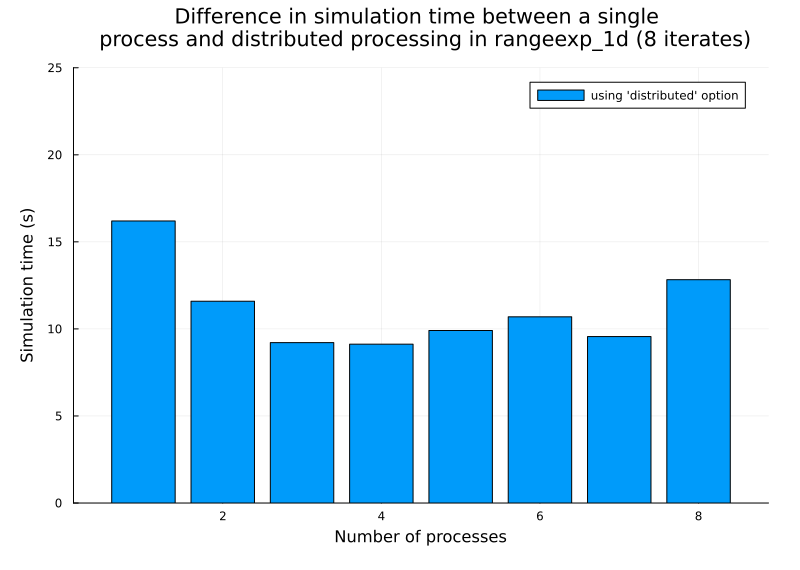

In [8]:
#Plots.bar(nothread_times,label="without 'distributed' option")
Plots.bar(thread_times,ylabel="Simulation time (s)",size=(800,570),ylims=(0,25),xlabel="Number of processes",label="using 'distributed' option",title="Difference in simulation time between a single \n process and distributed processing in rangeexp_1d (8 iterates)")

That is the main result we wanted to see in this short example.

Finally, let's just confirm that our simulations are working and non-trivial:

In [ ]:
temp_res = rangeexp_1d(50,50,4;distributed=true)

┌ Info: Saved animation to C:\Users\Hartree\AppData\Local\Temp\jl_IVc1SduFch.gif
└ @ Plots C:\Users\Hartree\.julia\packages\Plots\ju9dp\src\animation.jl:156


Plots.AnimatedGif("C:\\Users\\Hartree\\AppData\\Local\\Temp\\jl_IVc1SduFch.gif")
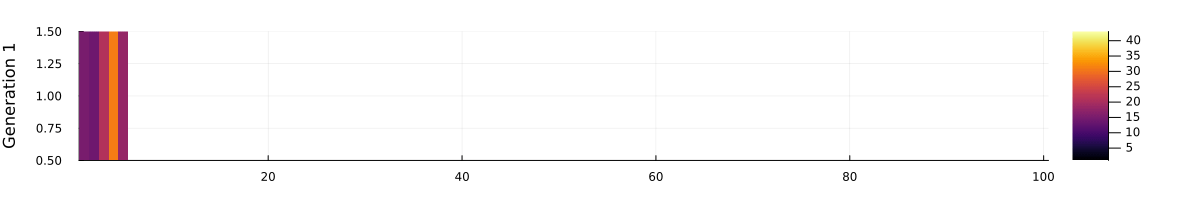

In [3]:
re_heatmap(temp_res["pops"][:,:,2],1,50,70;n_gens_sub=50)